In [ ]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt

# Notebook uses functions from .py scripts in scripts/ folder
sys.path.append('../scripts/calculate')

from metrics import bray_curtis_calc, spearman_corr

## Between-Group Compositional Analysis

In [2]:
# Load samples
W_gmr = pd.read_csv('../results/genera/random_split/reapply/W_5.csv', index_col=0)
W_cmd = pd.read_csv('../results/genera/random_split/nmf_trained/nsig_5/best_run/W_5.csv', index_col=0)

# Rename columns of Wcmd
es_columns = []
for c in range(W_cmd.shape[1]):
    es_genus = W_cmd.iloc[:, c].idxmax()
    es_name = f'ES_{es_genus[:4]}' if es_genus != 'Faecalibacterium' else 'ES_Firm'
    es_columns.append(es_name)
W_cmd.columns = es_columns

# Take only subset of common features
common = list(set(W_gmr.index) & set(W_cmd.index))
W_gmr = W_gmr.loc[common]
W_cmd = W_cmd.loc[common]

# Renormalize
W_gmr = W_gmr.div(W_gmr.sum(axis=0), axis=1)
W_cmd = W_cmd.div(W_cmd.sum(axis=0), axis=1)

### Scatterplot showing the pairwise Spearman correlation and Bray–Curtis dissimilarity

In [3]:
results = []

for col in range(W_cmd.shape[1]):
    # Extract corresponding components
    prop1 = W_gmr.iloc[:, col].values.astype(float)
    prop2 = W_cmd.iloc[:, col].values.astype(float)

    # Bray-Curtis dissimilarity
    dist = bray_curtis_calc(prop1, prop2)

    # Spearman correlation
    corr, _ = spearman_corr(prop1, prop2)

    results.append({
        'component': W_cmd.columns[col],
        'bray_curtis': dist,
        'correlation': corr
    })
results_df = pd.DataFrame(results)

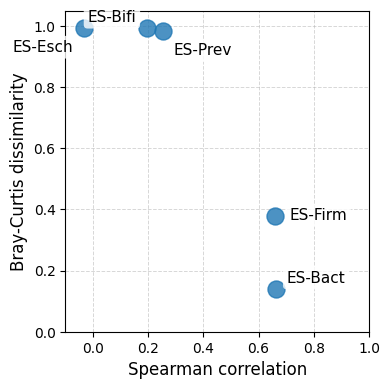

In [ ]:
# PLOT
fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(results_df['correlation'], results_df['bray_curtis'], s=150, alpha=0.8, zorder=3)

rename = {'ES_Bact':'ES-Bact', 'ES_Prev':'ES-Prev', 'ES_Bifi':'ES-Bifi', 'ES_Esch':'ES-Esch', 'ES_Firm':'ES-Firm'}

# Annotation positions
offsets = [
    (8, 8),
    (8, -14),
    (-8, 8),
    (-8, -14),
    (10, 0)
]

for i, (_, row) in enumerate(results_df.iterrows()):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        rename[row['component']],
        xy=(row['correlation'], row['bray_curtis']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=11,
        ha='left' if dx > 0 else 'right',
        va='center',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='none',
            alpha=0.8
        ),
        zorder=4
    )


# LIMITS
ax.set_xlim(-0.1, 1.0)
ax.set_ylim(0, 1.05)

#LABELS
ax.set_xlabel('Spearman correlation', fontsize=12)
ax.set_ylabel('Bray-Curtis dissimilarity',fontsize=12)

# Grid
ax.grid(
    True,
    which='major',
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    zorder=0
)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../images/WW_scatter.png', dpi=300)
plt.show()


### Heatmap showing the top five genera contributing to each ES in the CMD and GMR datasets, 

In [7]:
# Get top 5 genera across W_cmd and W_gmr for each ES
top_genera = set()

for col in range(W_cmd.shape[1]):
    top_genera.update(W_cmd.iloc[:, col].nlargest(5).index)
    top_genera.update(W_gmr.iloc[:, col].nlargest(5).index)

top_genera = list(top_genera)

# Build paired matrix: W_cmd, W_gmr for each component
data = []
row_labels = []

for col in W_cmd.columns:
    data.append(W_cmd.loc[top_genera, col].values)
    data.append(W_gmr.loc[top_genera, col].values)
    row_labels.extend([col, f'{col}_re'])

data = np.array(data)
data = data.T

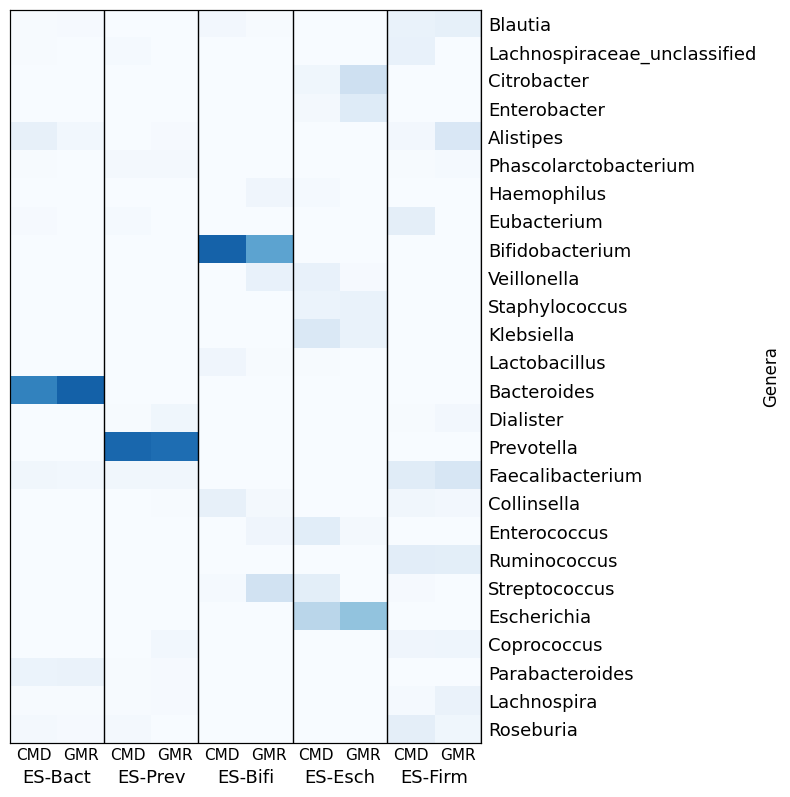

In [9]:
# PLOT heatmap
fig, ax = plt.subplots(figsize=(8, 8))

# Heatmap
im = ax.imshow(
    data,
    cmap='Blues',
    aspect='auto',
    vmin=0,
    vmax=1
)

# X-axis = components
ax.set_xticks(range(len(row_labels)))
ax.set_xticklabels(
    ['CMD', 'GMR',
     'CMD', 'GMR',
     'CMD', 'GMR',
     'CMD', 'GMR',
     'CMD', 'GMR'],
    rotation=0,
    fontsize=11
)

component_labels = [
    'ES-Bact',
    'ES-Prev',
    'ES-Bifi',
    'ES-Esch',
    'ES-Firm']

for i, label in enumerate(component_labels):
    center = i * 2 + 0.5
    ax.text(
        center,
        -0.06,
        label,
        transform=ax.get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=13)

# Vertical lines
for i in range(1, len(row_labels), 2):
    ax.axvline(x=i + 0.5, color='black', linewidth=1)

# Y labels
ax.set_yticks(range(len(top_genera)))
ax.set_yticklabels([])

ax_right = ax.twinx()

ax_right.set_ylim(ax.get_ylim())
ax_right.set_yticks(range(len(top_genera)))
ax_right.set_yticklabels(
    top_genera,
    fontsize=13)

ax_right.set_ylabel('Genera', fontsize=12)

# Keep labels on right only
ax_right.tick_params(
    axis='y',
    length=0,
    pad=5)

ax.tick_params(axis='both',length=0)

plt.tight_layout()
plt.savefig('../images/WW_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()